**Nguồn dataset:** https://drive.google.com/drive/folders/1xclbjHHK58zk2X6iqbvMPS2rcy9y9E0X

**Mô tả dataset:** Dataset UIT-VSFC (UIT – Vietnamese Students’ Feedback Corpus) là một bộ dữ liệu tiếng Việt được xây dựng để nghiên cứu các bài toán phân tích cảm xúc (sentiment analysis) và phân loại chủ đề (topic classification) từ các phản hồi của sinh viên về hoạt động giảng dạy tại trường đại học.

**Phương án làm việc với dữ liệu và mô hình:** 

* `sents.txt:` chứa nội dung phản hồi của sinh viên.
* `sentiments.txt:` chứa nhãn cảm xúc của từng câu.
* `topics.txt:` chứa nhãn chủ đề của từng câu.

Mỗi dòng trong các file tương ứng với cùng một mẫu dữ liệu, trong đó câu văn bản trong sents.txt được gán nhãn cảm xúc và nhãn chủ đề tương ứng trong hai file còn lại. 

Trong phạm vi bài thực hành này, dữ liệu được sử dụng để giải quyết bài toán phân loại cảm xúc (sentiment classification).

# Phần 1: NAIVE BAYES tự cài

In [1]:
train = [
("just plain boring", "-"),
("entirely predictable and lacks energy", "-"),
("no surprises and very few laughs", "-"),
("very powerful", "+"),
("the most fun film of the summer", "+")
]

test = "predictable with no fun"

## Xây vocabulary

Đoạn code này thực hiện bước tiền xử lý dữ liệu huấn luyện để chuẩn bị các thông tin cần thiết cho mô hình Naive Bayes. Cụ thể, chương trình sẽ tách các từ theo từng lớp nhãn, xây dựng tập từ vựng (vocabulary), đếm số lượng từ và tính xác suất tiên nghiệm (prior probability) của mỗi lớp.

In [ ]:
#1
Word_Positive = []
Word_Negative = []
Word_Total = []
y_train = []
Prior_Positive = 0
Prior_Negative = 0

for s in train:    
    if s[1] == "+":
        Word_Positive.extend(s[0].split())
        Prior_Positive += 1
    else:
        Word_Negative.extend(s[0].split())
        Prior_Negative += 1        
    y_train.append(s[1])
Word_Total = set(Word_Positive + Word_Negative)
Count_Positive = len(Word_Positive)
Count_Negative = len(Word_Negative)
Count_Total = len(Word_Total)
Prior_Positive /= len(y_train)
Prior_Negative /= len(y_train)

**Giải thích:** 

**Ở đoạn 1:** 

Các biến được khởi tạo nhằm lưu trữ thông tin từ dữ liệu huấn luyện:

| Biến  |	Ý nghĩa |
|-------|-----------|
|Word_Positive |	Danh sách tất cả các từ xuất hiện trong các câu có nhãn tích cực (+)
|Word_Negative|	Danh sách các từ xuất hiện trong các câu có nhãn tiêu cực (-)
|Word_Total|	Tập từ vựng của toàn bộ dữ liệu
|y_train|	Danh sách nhãn của các câu trong tập train
|Prior_Positive|	Biến đếm số lượng câu positive
|Prior_Negative|	Biến đếm số lượng câu negative

Những biến này được sử dụng để thu thập thống kê từ dữ liệu huấn luyện.

Cuối cùng, chương trình tính:

* Count_Positive: tổng số từ thuộc lớp positive
* Count_Negative: tổng số từ thuộc lớp negative
* Count_Total: số lượng từ khác nhau trong vocabulary

Đồng thời, xác suất tiên nghiệm của mỗi lớp được tính theo công thức:

P(c) = N(c) / N 

Trong đó N(c) là số câu thuộc lớp c và N là tổng số câu trong tập huấn luyện.

Các giá trị này sẽ được sử dụng ở bước tiếp theo để tính xác suất Naive Bayes khi dự đoán nhãn cho câu mới.

## Tính xác suất cho câu test

In [3]:
import math

test_words = [w for w in test.split() if w != "with"]
pos_prob = math.log(Prior_Positive)
neg_prob = math.log(Prior_Negative)

for w in test_words:    
    pw_pos = (Word_Positive.count(w)+1)/(Count_Positive+Count_Total)
    pw_neg = (Word_Negative.count(w)+1)/(Count_Negative+Count_Total)    
    pos_prob += math.log(pw_pos)
    neg_prob += math.log(pw_neg)

if pos_prob > neg_prob:
    print("Positive")
else:
    print("Negative")

Negative


**Giải thích:** 

Ở bước này, mô hình sẽ dự đoán nhãn của câu test dựa trên công thức của Naive Bayes.

Trước tiên, câu test được tách thành các từ riêng lẻ. Trong ví dụ này, từ "with" được loại bỏ vì nó không mang nhiều ý nghĩa trong việc phân loại cảm xúc.

Sau đó, xác suất của từng lớp được khởi tạo bằng log của prior probability:

* pos_prob = log(P(positive))
* neg_prob = log(P(negative))

Tiếp theo, chương trình duyệt qua từng từ trong câu test và tính xác suất có điều kiện: 

P(w/c) = (count(w in c) + 1) / (total_words_in_c + V)

Trong đó:
- count(w in c): số lần từ w xuất hiện trong lớp c
- total_words_in_c: tổng số từ trong lớp c
- |V|: là kích thước của vocabulary

Việc cộng 1 trong công thức được gọi là Laplace Smoothing, giúp tránh trường hợp xác suất bằng 0 khi một từ chưa từng xuất hiện trong tập huấn luyện.

Các xác suất được cộng dồn dưới dạng log probability để tránh lỗi tràn số khi nhân nhiều xác suất nhỏ.

Cuối cùng, lớp có xác suất lớn hơn sẽ được chọn làm kết quả dự đoán của câu test.

# 2 SKLEARN NAIVE BAYES 

## Chuẩn bị dữ liệu

In [4]:
X_train = [s for s,l in train]
y_train = [l for s,l in train]
X_test = [test]

## Vectorize

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

## Encode label

In [6]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)

## Train model

In [7]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train_enc)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Predict

In [8]:
y_pred = model.predict(X_test_vec)
encoder.inverse_transform(y_pred)

array(['-'], dtype='<U1')

# 3 N-GRAM

## 1-gram

In [9]:
cv = CountVectorizer(ngram_range=(1,1))

## 2-gram

In [10]:
cv = CountVectorizer(
    analyzer="word",
    ngram_range=(2,2)
)

## 1-gram + 2-gram

In [11]:
cv = CountVectorizer(
    ngram_range=(1,2)
)

# 4 DATASET UIT-VSFC

## Đọc dữ liệu

In [13]:
with open("train/sents.txt",encoding="utf-8") as f:
    X_train = f.read().splitlines()
with open("train/sentiments.txt",encoding="utf-8") as f:
    y_train = [int(x) for x in f.read().splitlines()]
with open("test/sents.txt",encoding="utf-8") as f:
    X_test = f.read().splitlines()
with open("test/sentiments.txt",encoding="utf-8") as f:
    y_test = [int(x) for x in f.read().splitlines()]

# 5 Count VECTORIZER

In [14]:
cv = CountVectorizer()
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

# 6 Train NAIVE BAYES

In [15]:
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
y_pred = nb.predict(X_test_vec)

# 7. Accuracy

In [16]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.8401768793430195

# 8. Macro F1

In [17]:
from sklearn.metrics import f1_score

f1_score(y_test,y_pred,average="macro")

0.6299946889576669

# 9. Confusion Matrix

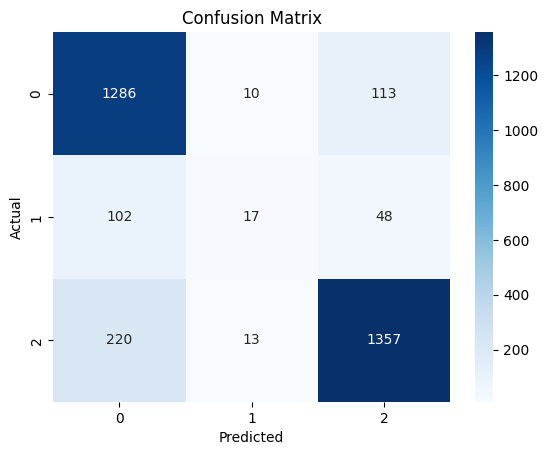

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 10 Bổ sung thêm: 

## So sánh 1-gram vs 2-gram

In [20]:
cv = CountVectorizer(ngram_range=(1,2))
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)
nb.fit(X_train_vec,y_train)
y_pred = nb.predict(X_test_vec)
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8584965255843335


## TF-IDF Vectorizer

**Import thư viện:**

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

**Vectorize dữ liệu**

In [22]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**Train Naive Bayes với TF-IDF**

In [23]:
from sklearn.naive_bayes import MultinomialNB

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

**Accuracy**

In [24]:
print("NB + TFIDF Accuracy:", accuracy_score(y_test, y_pred_nb_tfidf))

NB + TFIDF Accuracy: 0.8401768793430195


**Macro-F1**

In [25]:
print("NB + TFIDF F1:", f1_score(y_test, y_pred_nb_tfidf, average="macro"))

NB + TFIDF F1: 0.575343607988104


## Logistic Regression

**Import thư viện:**

In [26]:
from sklearn.linear_model import LogisticRegression

**Train model**

In [27]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

**Accuracy Logistic Regression**

In [28]:
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))

LR Accuracy: 0.8806064434617814


**Macro-F1**

In [29]:
print("LR F1:", f1_score(y_test, y_pred_lr, average="macro"))

LR F1: 0.6512007544554496


**Confusion Matrix**

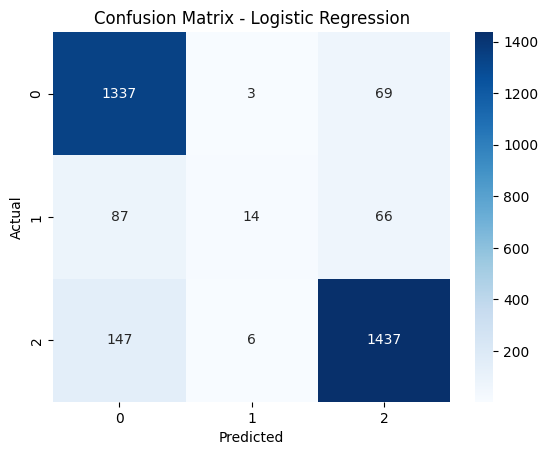

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**So sánh các mô hình**

In [ ]:
print("NB + CountVectorizer Accuracy:", accuracy_score(y_test, y_pred))
print("NB + TFIDF Accuracy:", accuracy_score(y_test, y_pred_nb_tfidf))
print("LR + TFIDF Accuracy:", accuracy_score(y_test, y_pred_lr))

NB + CountVectorizer Accuracy: 0.8584965255843335
NB + TFIDF Accuracy: 0.8401768793430195
LR + TFIDF Accuracy: 0.8806064434617814


: 